# `graphs` — candidate track-graph construction

`graphs` turns a `detectorsim2d` hits table into a graph — nodes are hits,
edges are *candidate* hit-to-hit connections — under a configurable,
YAML-driven **prescription**. It works on hits from any `detector2d`
layout without caring which, since only `x`, `y`, `layer_id`, and
`event_id` are ever used, never the layer geometry itself.

A `TrackGraph` is just two DataFrames: `nodes` (the hits table, unmodified)
and `edges` (`event_id, edge_id, src_hit_id, dst_hit_id, delta_layer_id,
delta_r, delta_phi, delta_x, delta_y, distance`, always `dst - src`).
Crucially, `graphs.build` never looks at `particle_id` — building the
candidate graph works the same way it would on real data, where ground
truth doesn't exist. Truth-labeling (`is_true_edge`) is a deliberately
separate, optional second step.


In [8]:
%matplotlib inline
import numpy as np

from detectorsim2d.config import load_config as load_sim_config
from detectorsim2d.simulate import simulate_events

from graphs.config import load_config as load_graph_config
from graphs.build import build_graph
from graphs.truth import label_graph, purity
from graphs.vis import plot_event_with_graph, plot_event


In [2]:
sim_config = load_sim_config("../aihep/simulator/detectorsim2d/configs/barrel6.yaml")
particles, hits, deposits = simulate_events(sim_config, rng=np.random.default_rng(3))
print(f"{len(hits)} hits across {particles['event_id'].nunique()} events")


107 hits across 1 events


## Three prescriptions, same event

- **`fully_connected`** — every hit connects to every other hit in the
  event. Quadratic in hit count, and (as you'll see) very low purity: most
  candidate edges connect unrelated tracks.
- **`regional`** — bucket hits into `phi_width`-wide azimuthal sectors and
  fully-connect only within a sector. A pure spatial-locality cut, no
  wraparound stitching across a sector boundary.
- **`connection_rules`** — connect `i -> j` only if every given signed delta
  (`delta_layer_id`, `delta_r`, `delta_phi`, ...) falls in its configured
  range. An asymmetric range encodes direction (outward-only); a symmetric
  one allows both.

`label_graph`/`purity` (opt-in, uses truth `particle_id`) measure the
fraction of edges that connect the *same* particle — a proxy for how much
work a downstream GNN edge classifier would have to do to clean up each
prescription's candidates.


In [3]:
for name in ["fully_connected", "regional", "connection_rules"]:
    graph_config = load_graph_config(f"../aihep/tracking/graphs/configs/{name}.yaml")
    graph = build_graph(hits, graph_config.prescription)
    labeled = label_graph(graph)
    print(f"{name:>18s}: {len(graph.edges):5d} edges, purity {purity(labeled.edges):.3f}")


   fully_connected:  5671 edges, purity 0.059
          regional:   831 edges, purity 0.338
  connection_rules:   478 edges, purity 0.383


## Visualizing each prescription

`plot_event_with_graph` draws `detectorsim2d.vis.plot_event` (detector
layers, trajectories, hits) with the graph's edges underneath, colored more
boldly where `is_true_edge` is `True`.


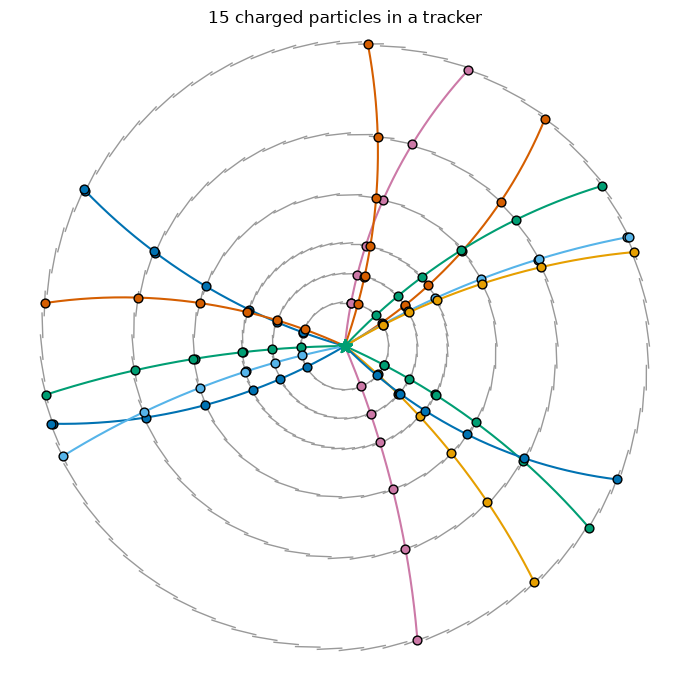

In [11]:
from viz_style import  PRINT, PRESENT, use_theme
with use_theme(PRESENT):
    full_config = load_sim_config("../aihep/simulator/detectorsim2d/configs/barrel6.yaml")
    fig = plot_event(particles, hits, full_config.layers, event_id=0, deposits=deposits)
    fig.suptitle(f"15 charged particles in a tracker")


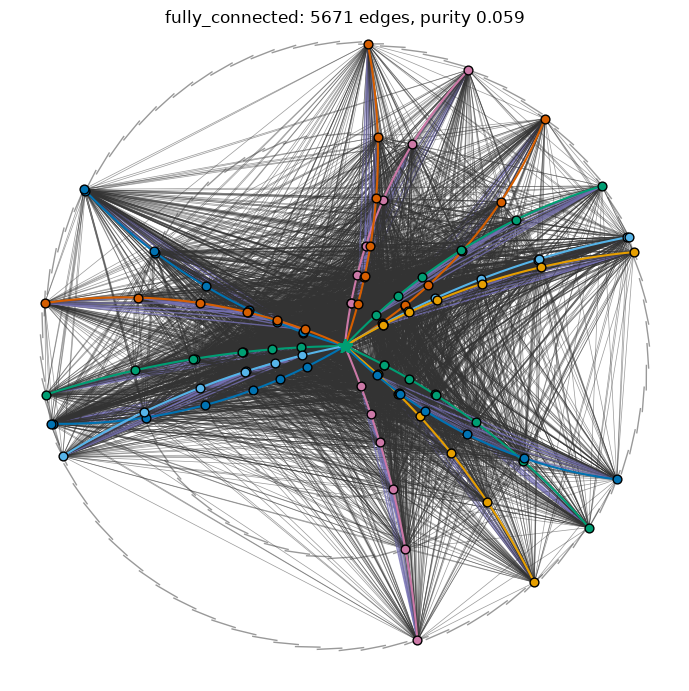

In [ ]:
from viz_style import  PRINT, PRESENT, use_theme
with use_theme(PRESENT):
    graph_config = load_graph_config("../aihep/tracking/graphs/configs/fully_connected.yaml")
    graph = label_graph(build_graph(hits, graph_config.prescription))
    fig = plot_event_with_graph(particles, hits, graph.edges, sim_config.layers, event_id=0)
    fig.suptitle(f"fully_connected: {len(graph.edges)} edges, purity {purity(graph.edges):.3f}")


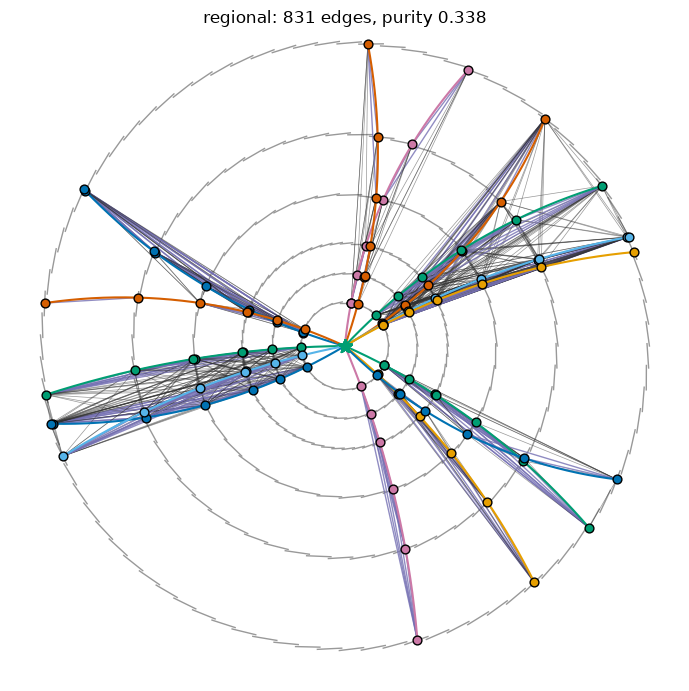

In [ ]:
from viz_style import  PRINT, PRESENT, use_theme
with use_theme(PRESENT):
    graph_config = load_graph_config("../aihep/tracking/graphs/configs/regional.yaml")
    graph = label_graph(build_graph(hits, graph_config.prescription))
    fig = plot_event_with_graph(particles, hits, graph.edges, sim_config.layers, event_id=0)
    fig.suptitle(f"regional: {len(graph.edges)} edges, purity {purity(graph.edges):.3f}")


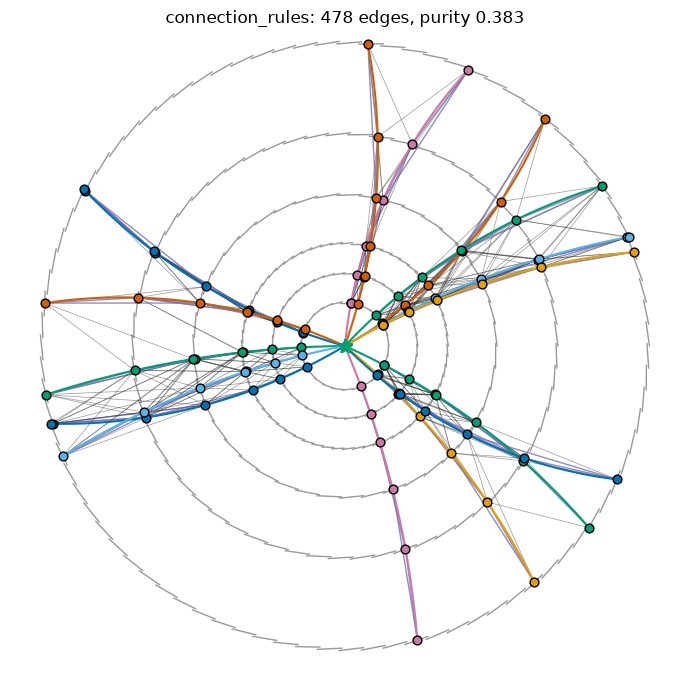

In [7]:
from viz_style import  PRINT, PRESENT, use_theme
with use_theme(PRESENT):
    graph_config = load_graph_config("../aihep/tracking/graphs/configs/connection_rules.yaml")
    graph = label_graph(build_graph(hits, graph_config.prescription))
    fig = plot_event_with_graph(particles, hits, graph.edges, sim_config.layers, event_id=0)
    fig.suptitle(f"connection_rules: {len(graph.edges)} edges, purity {purity(graph.edges):.3f}")


Each successive prescription trades edge count for purity: `fully_connected`
keeps every possible connection (lowest purity, most work for a downstream
classifier); `connection_rules`' physically-motivated cuts (mostly-outward,
narrow azimuthal window) get the fewest, highest-purity candidates — at the
cost of being the most hand-tuned to this specific detector's geometry.


## Building a prescription directly (no YAML)

`Prescription` dataclasses can be constructed directly, the same way
`detector2d` layers can be hand-built without a config file:


In [ ]:
from graphs.prescription import ConnectionRules

prescription = ConnectionRules(delta_layer_id=(1.0, 1.0))
graph = build_graph(hits, prescription)
print(f"next-layer-only: {len(graph.edges)} edges")
